 ---
# **Q. Gini impurity and entropy from scratch**
---



In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gini(p):
    """p = array of class proportions in a node, e.g. [0.5, 0.5]"""
    p = np.array(p)
    return 1 - np.sum(p**2)

def entropy(p):
    """Shannon entropy in bits"""
    p = np.array(p)
    p = p[p > 0]  # avoid log(0)
    return -np.sum(p * np.log2(p))

# Compare impurity for different splits of a binary class node
splits = {
    "Pure node       [10, 0]":  [1.0, 0.0],
    "Slightly mixed  [9, 1]":   [0.9, 0.1],
    "Mixed           [7, 3]":   [0.7, 0.3],
    "Maximally mixed [5, 5]":   [0.5, 0.5],
}

print(f"{'Node':28s} {'Gini':>8s} {'Entropy':>8s}")
print("-" * 46)
for name, p in splits.items():
    print(f"{name:28s} {gini(p):8.4f} {entropy(p):8.4f}")

Node                             Gini  Entropy
----------------------------------------------
Pure node       [10, 0]        0.0000  -0.0000
Slightly mixed  [9, 1]         0.1800   0.4690
Mixed           [7, 3]         0.4200   0.8813
Maximally mixed [5, 5]         0.5000   1.0000


---
# **Q. plot both curves across all possible proportions**
---



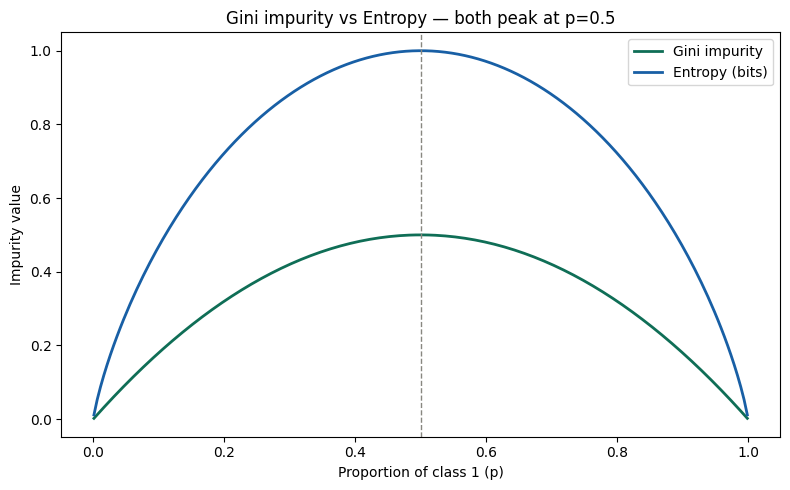

Max Gini (at p=0.5):    0.5000
Max Entropy (at p=0.5): 1.0000

Both metrics are 0 at p=0 or p=1 (pure node)
Both metrics peak at p=0.5 (maximally mixed node)
Entropy's curve is taller and uses log2 — slightly more computation


In [2]:
p1 = np.linspace(0.001, 0.999, 200)
gini_vals    = [gini([p, 1-p]) for p in p1]
entropy_vals = [entropy([p, 1-p]) for p in p1]

plt.figure(figsize=(8, 5))
plt.plot(p1, gini_vals, color='#0F6E56', linewidth=2, label='Gini impurity')
plt.plot(p1, entropy_vals, color='#185FA5', linewidth=2, label='Entropy (bits)')
plt.axvline(0.5, color='#888780', linestyle='--', linewidth=1)
plt.xlabel('Proportion of class 1 (p)')
plt.ylabel('Impurity value')
plt.title('Gini impurity vs Entropy — both peak at p=0.5')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Max Gini (at p=0.5):    {gini([0.5,0.5]):.4f}")
print(f"Max Entropy (at p=0.5): {entropy([0.5,0.5]):.4f}")
print("\nBoth metrics are 0 at p=0 or p=1 (pure node)")
print("Both metrics peak at p=0.5 (maximally mixed node)")
print("Entropy's curve is taller and uses log2 — slightly more computation")

---
# **Q. fit a decision tree on Iris and visualise it**
---



Train accuracy: 1.0000
Test accuracy:  0.9333


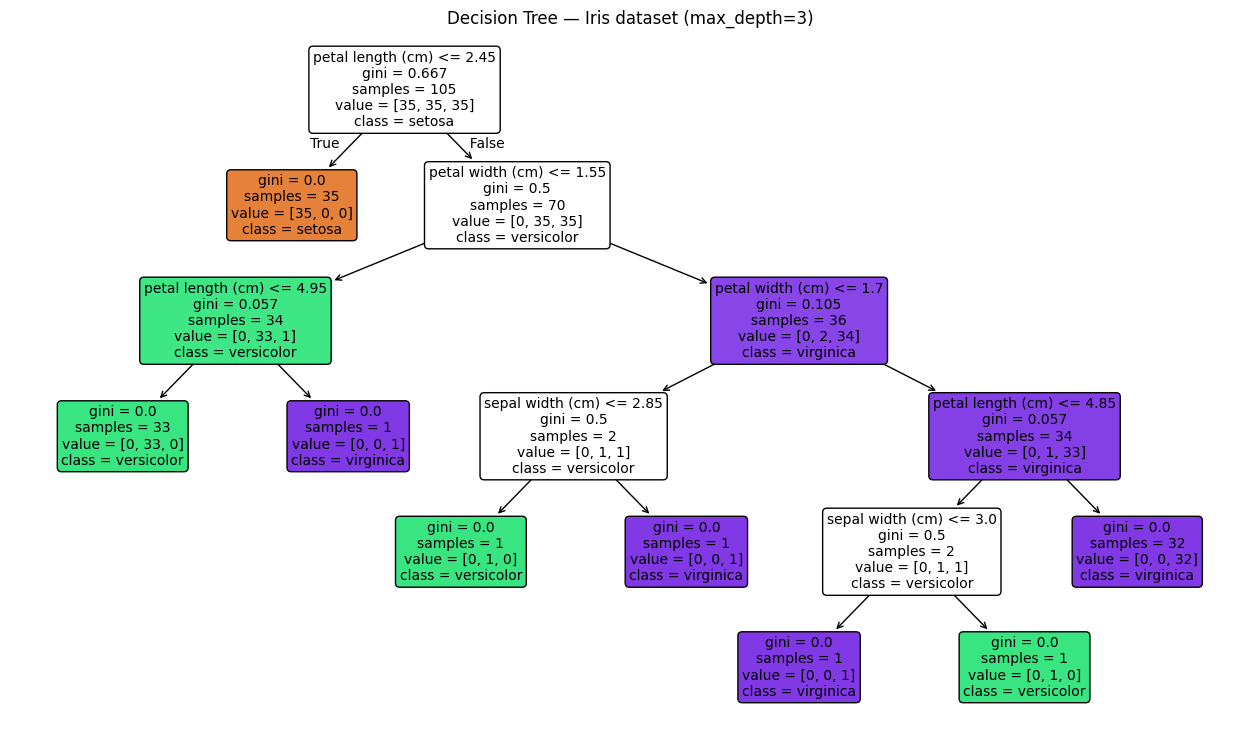

In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Limit depth to 3 so the tree is readable
clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(X_train, y_train)

print(f"Train accuracy: {clf.score(X_train, y_train):.4f}")
print(f"Test accuracy:  {clf.score(X_test, y_test):.4f}")

plt.figure(figsize=(16, 9))
plot_tree(clf, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree — Iris dataset (max_depth=3)")
plt.show()

#Insights:
---
How to read the tree diagram: Each box shows the splitting condition (e.g. "petal width ≤ 0.8"), the Gini value of that node, the number of samples, the class distribution (value=[...]), and the predicted class. Darker colour = purer node. Notice the very first split uses petal width — this is the single most discriminative feature for separating setosa from the other two species.

---
# **Q.Compute Gini impurity by hand for a node with 50 samples of class A and 50 of class B. Then for a node with 90 A and 10 B. Verify with code.**
---



In [4]:
def gini(p):
    p = np.array(p)
    return 1 - np.sum(p**2)

node1 = gini([50/100, 50/100])
node2 = gini([90/100, 10/100])

print(f"Node 1 (50/50): Gini = {node1:.4f}")
print(f"Node 2 (90/10): Gini = {node2:.4f}")
print(f"\nNode 2 is {'more' if node2 < node1 else 'less'} pure than Node 1")
print(f"Difference: {node1 - node2:.4f}")

Node 1 (50/50): Gini = 0.5000
Node 2 (90/10): Gini = 0.1800

Node 2 is more pure than Node 1
Difference: 0.3200


#Insights
---
Why this matters: A decision tree algorithm scans every possible split and picks the one that produces child nodes with the lowest weighted average Gini. A split producing two 90/10 nodes is far more valuable than one producing two 50/50 nodes — the 90/10 nodes are "almost decided" while 50/50 nodes are a coin flip.

---
# **Q.Compute entropy for the same two splits (50/50 and 90/10). Compare the relative difference between Gini and entropy**
---


In [5]:
def entropy(p):
    p = np.array(p)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

g1, g2 = gini([0.5,0.5]), gini([0.9,0.1])
e1, e2 = entropy([0.5,0.5]), entropy([0.9,0.1])

print(f"{'Split':10s} {'Gini':>8s} {'Entropy':>8s} {'Entropy/Gini':>13s}")
print("-" * 42)
print(f"{'50/50':10s} {g1:8.4f} {e1:8.4f} {e1/g1:13.3f}")
print(f"{'90/10':10s} {g2:8.4f} {e2:8.4f} {e2/g2:13.3f}")

print(f"\nGini drop (50/50 → 90/10):    {g1-g2:.4f}  ({(g1-g2)/g1*100:.1f}% reduction)")
print(f"Entropy drop (50/50 → 90/10): {e1-e2:.4f}  ({(e1-e2)/e1*100:.1f}% reduction)")

Split          Gini  Entropy  Entropy/Gini
------------------------------------------
50/50        0.5000   1.0000         2.000
90/10        0.1800   0.4690         2.606

Gini drop (50/50 → 90/10):    0.3200  (64.0% reduction)
Entropy drop (50/50 → 90/10): 0.5310  (53.1% reduction)


#Insights:
---
The key takeaway: Entropy is roughly 2x Gini at p=0.5 but the ratio changes as p moves away from 0.5 — they are NOT linearly related. However, both functions are concave, both equal 0 at pure nodes, and both peak at p=0.5. In practice, trees grown with 'gini' vs 'entropy' as criterion produce nearly identical splits — the choice rarely matters for final accuracy. Gini is preferred by default because it avoids computing logarithms, making it slightly faster.

---
# **Q.Manually compute information gain for the first split sklearn chose on the Iris tree (petal width ≤ 0.8).**
---


In [6]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target
petal_width = X[:, 3]  # 4th column = petal width

# The root node before any split
parent_gini = gini(np.bincount(y) / len(y))
print(f"Parent node Gini (all 150 samples, 3 classes): {parent_gini:.4f}")
print(f"Class counts: {np.bincount(y)}  (50 each)")

# Apply the split sklearn chose: petal width <= 0.8
left_mask  = petal_width <= 0.8
right_mask = ~left_mask

y_left, y_right = y[left_mask], y[right_mask]
n_left, n_right, n_total = len(y_left), len(y_right), len(y)

gini_left  = gini(np.bincount(y_left,  minlength=3) / n_left)
gini_right = gini(np.bincount(y_right, minlength=3) / n_right)

print(f"\nLeft node  (petal width <= 0.8): n={n_left:3d}  "
      f"class counts={np.bincount(y_left, minlength=3)}  Gini={gini_left:.4f}")
print(f"Right node (petal width >  0.8): n={n_right:3d}  "
      f"class counts={np.bincount(y_right, minlength=3)}  Gini={gini_right:.4f}")

# Weighted average Gini of children
weighted_gini = (n_left/n_total)*gini_left + (n_right/n_total)*gini_right

# Information gain = parent impurity - weighted child impurity
info_gain = parent_gini - weighted_gini
print(f"\nWeighted child Gini: {weighted_gini:.4f}")
print(f"Information gain:    {info_gain:.4f}")

Parent node Gini (all 150 samples, 3 classes): 0.6667
Class counts: [50 50 50]  (50 each)

Left node  (petal width <= 0.8): n= 50  class counts=[50  0  0]  Gini=0.0000
Right node (petal width >  0.8): n=100  class counts=[ 0 50 50]  Gini=0.5000

Weighted child Gini: 0.3333
Information gain:    0.3333


#Insights:
---
Why sklearn chose this split: This single split achieves a perfect separation of setosa (left node is 100% pure, Gini=0) from the other two species, cutting overall impurity in half (0.667 → 0.333). No other single feature/threshold combination on this dataset achieves a larger information gain at the root — which is exactly why the algorithm picked it first.

---
# **Q. Grow the Iris tree with no max_depth limit. How many leaves does it have? Plot it and compare readability to the depth-3 tree.**
---



Tree depth:        5
Number of leaves:  8
Total nodes:       15

Train accuracy: 1.0000
Test accuracy:  0.9333

--- Depth-3 tree (from Step 3) ---
Tree depth:        5
Number of leaves:  8
Train accuracy: 1.0000
Test accuracy:  0.9333


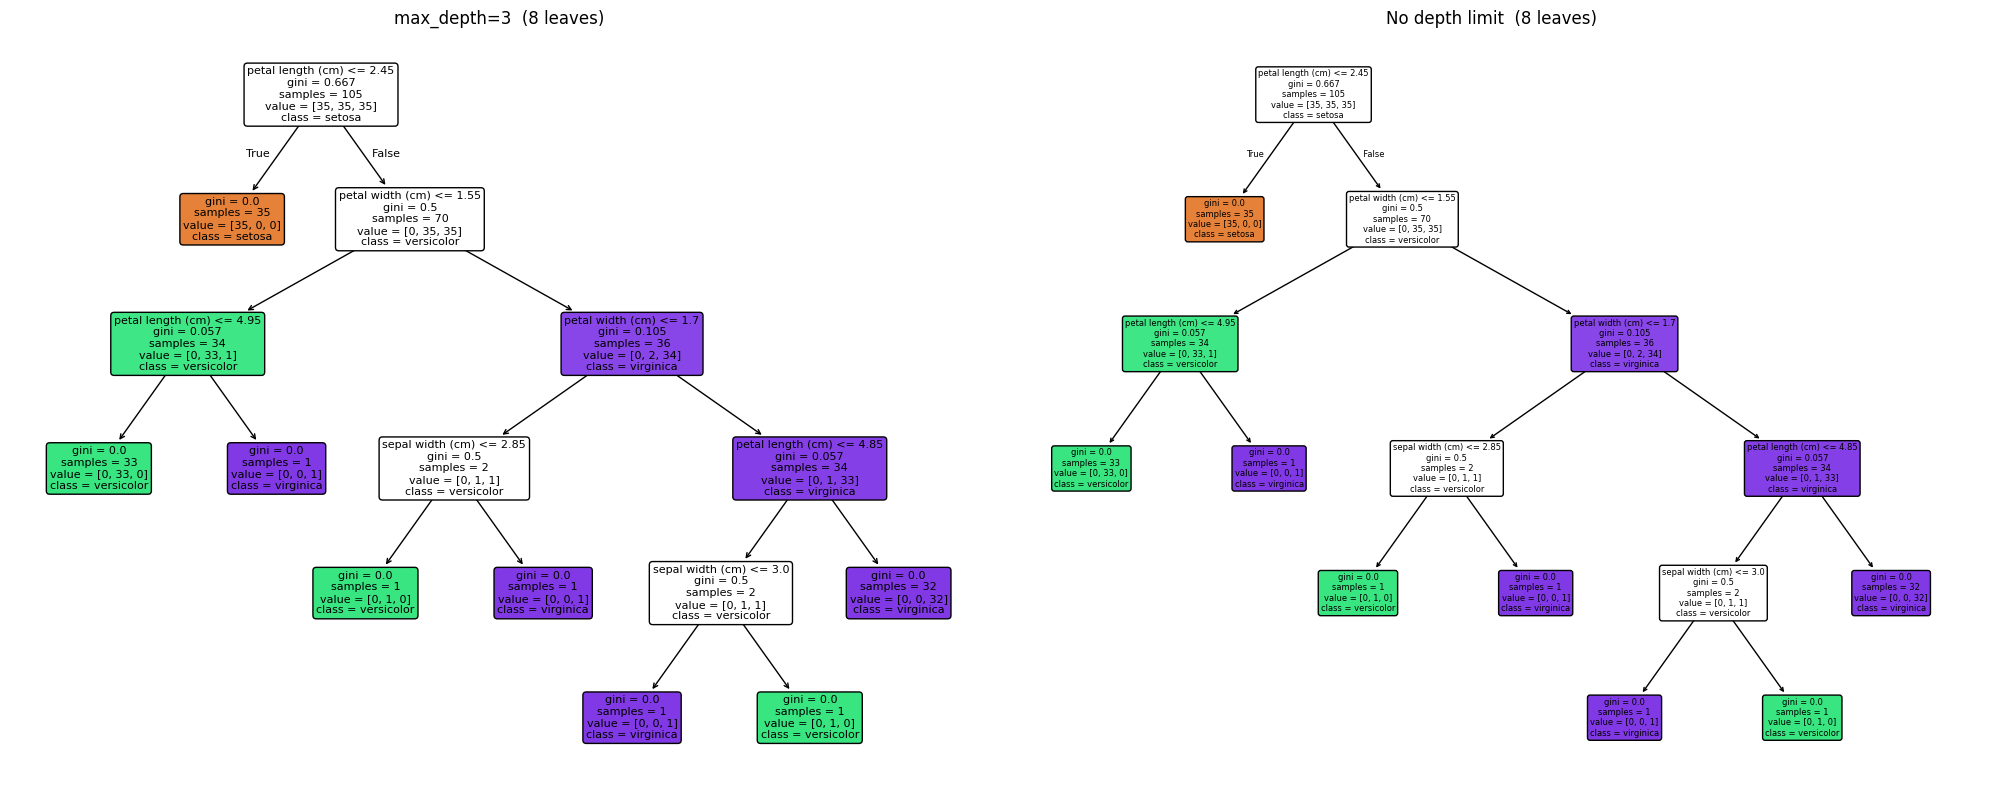

In [7]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# No depth limit
clf_full = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_full.fit(X_train, y_train)

print(f"Tree depth:        {clf_full.get_depth()}")
print(f"Number of leaves:  {clf_full.get_n_leaves()}")
print(f"Total nodes:       {clf_full.tree_.node_count}")
print(f"\nTrain accuracy: {clf_full.score(X_train, y_train):.4f}")
print(f"Test accuracy:  {clf_full.score(X_test, y_test):.4f}")

# Compare to depth-3
print(f"\n--- Depth-3 tree (from Step 3) ---")
print(f"Tree depth:        {clf.get_depth()}")
print(f"Number of leaves:  {clf.get_n_leaves()}")
print(f"Train accuracy: {clf.score(X_train, y_train):.4f}")
print(f"Test accuracy:  {clf.score(X_test, y_test):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plot_tree(clf, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=8, ax=axes[0])
axes[0].set_title(f"max_depth=3  ({clf.get_n_leaves()} leaves)")

plot_tree(clf_full, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=6, ax=axes[1])
axes[1].set_title(f"No depth limit  ({clf_full.get_n_leaves()} leaves)")
plt.tight_layout()
plt.show()

#Insights:
---
The overfitting signal is right here: The unconstrained tree reaches 100% train accuracy (memorising every training point exactly) but its TEST accuracy is actually LOWER than the depth-3 tree (0.956 vs 0.978). The extra depth and leaves are fitting noise in the training data, not real patterns. This is your first hands-on proof that "more complex = better" is false — and it sets up tomorrow's lesson perfectly